# continuity

> Estimate and correct discontinuities between adjacent detectors.

In [ ]:
# | default_exp euclid.continuity

In [ ]:
# | exporti

from astropy.io import fits
import numpy as np
from spherical_geometry.polygon import SphericalPolygon
import warnings
from regions import RectanglePixelRegion, PixCoord
from astropy.wcs import WCS
from regions import PolygonSkyRegion
from astropy.coordinates import SkyCoord
import astropy.units as u
from numpy.linalg import lstsq

from nicl.euclid.constants import NISP, VIS
from nicl.euclid.utilities import (
    get_dither_id_from_filename,
)
from nicl.utilities import does_image_overlap_with_skyregion, sigma_clip_stats

In [ ]:
# | hide
# additional imports for examples
%reload_ext autoreload
%autoreload now -p -l

from nicl.euclid.utilities import default_data_path, assemble_fpa_mosaic
from nicl.utilities import compute_pixel_scales
from matplotlib import pyplot as plt
from astropy.visualization import ImageNormalize, ZScaleInterval

In [ ]:
# | export

def get_overlap_chip(hdr, hdul, chip_layout, threshold=0.01):
    """Get the chip id (target dither) that overlaps with the chip pair in the current dither. Use regions for coarse overlap check."""
    nx, ny = hdr["NAXIS1"], hdr["NAXIS2"]
    pix_reg = RectanglePixelRegion(
        center=PixCoord((nx - 1) / 2, (ny - 1) / 2), width=nx, height=ny
    )
    sky_reg = pix_reg.to_sky(WCS(hdr))
    chips = []
    for chip in np.nditer(chip_layout):
        chip = str(chip)
        hdr = hdul[chip+".SCI"].header
        is_overlapped = does_image_overlap_with_skyregion(hdr, sky_reg, threshold=threshold)
        if is_overlapped:
            chips.append(chip)
    return chips
    
def compute_offset_between_chips(hdu, target_hdus, steps=10):
    """Compute the offsets between the overlapping chips in the target dither and the given chip in the current dither.
    """
    # use SphericalPolygon to compute the accurate overlap region
    current_poly = SphericalPolygon.from_wcs(hdu.header, steps=steps)
    offsets = []
    for target_hdu in target_hdus:
        target_poly = SphericalPolygon.from_wcs(target_hdu.header, steps=steps)
        if not current_poly.intersects_poly(target_poly):
            raise ValueError(f"Chip {target_hdu.header['extname']} does not overlap with the current dither chip {hdu.header['extname']}.")
        overlap_poly = current_poly.intersection(target_poly)
        sb, sb_err = polygon_photometry(overlap_poly, hdu)
        target_sb, target_sb_err = polygon_photometry(overlap_poly, target_hdu)
        # compute the offset
        offset = sb - target_sb
        offset_err = np.sqrt(sb_err**2 + target_sb_err**2)
        offsets.append((offset, offset_err))
    return offsets
            
def polygon_photometry(skyreg, hdu):
    """Perform polygon photometry on the given data using the provided sky region and WCS.
    This function computes the mean value of the pixels within the polygon region.
    """
    img = hdu.data
    hdr = hdu.header
    sky_area = skyreg.area()
    # get magnitude zero point; MAGZEROP is for VIS, ZPAB is the default key for NISP
    if "QUAD_ID" in hdr:
        target_mag_zpt = 24.56605
        target_pix_scl = 0.1
        mag_zpt = hdr.get("MAGZEROP")
    else:
        target_mag_zpt = 30
        target_pix_scl = 0.3
        mag_zpt = hdr.get("ZPAB")
    if mag_zpt is None:
        raise ValueError("Magnitude zero point not found in header (missing MAGZEROP and ZPAB keys)")
    # construct a PolygonSkyRegion to do photometry
    ra, dec = list(skyreg.to_radec())[0]
    skyreg_ = PolygonSkyRegion(SkyCoord(ra[:-1], dec[:-1], unit="deg"))
    # Convert the sky region to pixel coordinates
    wcs = WCS(hdr)
    pixreg = skyreg_.to_pixel(wcs)
    # mode="exact" not implemented in regions yet for polygons
    # also we don't need accurate pixel footprint since we are taking the mean/median
    regmask = pixreg.to_mask(mode="center")
    nanmask = np.isnan(img)
    extracted_data = regmask.get_values(img, mask=nanmask)
    # print(extracted_data)
    robust_mean, _, _, robust_mean_err = sigma_clip_stats(extracted_data, sigma_upper=2.5, sigma_lower=3, ngood_min=3)
    # print(f"robust mean: {robust_mean}, robust mean error: {robust_mean_err}")
    if not np.isnan(robust_mean):
        pix_area = pixreg.area
        # convert sky area from steradians to square arcseconds
        sky_area = sky_area * (180 * 3600 / np.pi)**2
        sky_area_per_pix = sky_area / pix_area
        # sky_area_per_pix=wcs.proj_plane_pixel_area().to(u.arcsec**2).value
        # print(f"sky area per pixel: {sky_area_per_pix}")
        # generalize to the same zpt and pixel scale
        adjusted_intensity = robust_mean / sky_area_per_pix * target_pix_scl**2 * 10**(-0.4 * (mag_zpt - target_mag_zpt))
        adjusted_intensity_error = robust_mean_err / sky_area_per_pix * target_pix_scl**2 * 10**(-0.4 * (mag_zpt - target_mag_zpt))
        # adjusted_intensity = robust_mean / sky_area_per_pix * target_pix_scl**2 
        # adjusted_intensity_error = robust_mean_err / sky_area_per_pix * target_pix_scl**2
        # adjusted_intensity = robust_mean
        # adjusted_intensity_error = robust_mean_err
        return adjusted_intensity, adjusted_intensity_error
    else:
        return np.nan, np.nan

        
def form_dither_pairs(dithers):
    """Form dither pairs from the list of dither files. It removes short exposures for now.
    """
    dithers.sort()
    dithers_=[]
    for dither in dithers:
        dither_id=get_dither_id_from_filename(dither)
        if len(dither_id)>1 and dither_id.endswith("1"):
            continue
        dithers_.append(dither)
    # form unique dither pairs among four dithers
    dither_pairs = []
    for i in range(len(dithers_)):
        for j in range(i+1, len(dithers_)):
            dither_pairs.append((dithers_[i], dithers_[j]))
    return dither_pairs

def _mask_in_place(hdu, mask):
    """Mask the data in place. So we don't need to pass around the dq hdu.
    """
    if mask is None:
        return
    if hdu.data is None:
        raise ValueError("Data is None")
    if mask.shape != hdu.data.shape:
        raise ValueError("Mask shape does not match data shape")
    # mask the data in place
    hdu.data[mask] = np.nan

In [ ]:
# | export


def measure_offset_per_dither_pair(dither_pair, instrument):
    dither1, dither2 = dither_pair
    chip_pairs= []
    offsets = []
    with fits.open(dither1) as hdul1, fits.open(dither2) as hdul2:
        # collect all headers from hdul2
        # target_hdrs = [hdul2[chip + ".SCI"].header for chip in np.nditer(instrument.chip_layout)]
        # loop over chips in hdul1
        for chip in np.nditer(instrument.chip_layout):
            chip=str(chip)
            hdr = hdul1[chip + ".SCI"].header
            target_chips = get_overlap_chip(hdr, hdul2, instrument.chip_layout)
            # measure the offset between the chips in dither1 and dither2
            # first mask out bad pixels
            if instrument.name == "VIS":
                dq_img = hdul1[chip + ".FLG"].data
                # additional bits: bright star, detected sources
                bits = list(instrument.bad_pix_bits) + [18, 24]
            elif instrument.name == "NISP":
                dq_img = hdul1[chip + ".DQ"].data
                # additional bits: scattered Light, moving Object, Transients; unfortunately no bit for detected sources
                bits = list(instrument.bad_pix_bits) + [19, 20, 21]
            mask = np.any(
                [(dq_img & 2**bit > 0) for bit in bits],
                axis=0,
            )
            _mask_in_place(hdul1[chip + ".SCI"], mask)
            for target_chip in target_chips:
                if instrument.name == "VIS":
                    dq_img = hdul2[target_chip + ".FLG"].data
                elif instrument.name == "NISP":
                    dq_img = hdul2[target_chip + ".DQ"].data
                mask = np.any(
                    [(dq_img & 2**bit > 0) for bit in bits],
                    axis=0,
                )
                _mask_in_place(hdul2[target_chip + ".SCI"], mask)
            hdus = [hdul2[chip + ".SCI"] for chip in target_chips]
            offset = compute_offset_between_chips(hdul1[chip + ".SCI"], hdus)
            chip_pairs.extend([(chip, target_chip) for target_chip in target_chips])
            offsets.extend(offset)
        # print(offsets, chip_pairs)
        res = {"instrument": instrument, "dither pair": dither_pair, "chip pair": chip_pairs, "offset": offsets}
        return res
    
def measure_offset_per_observation(dir, obsid, instrument, filter):
    """Measure the offset between the overlapping chips among the dithers of one observation.
    """
    if filter not in instrument.filters:
        raise ValueError(f"Filter {filter} is not available for {instrument.name}.")
    if instrument.name == "VIS":
        filter = ""
    # find the dither files
    dithers = list(dir.glob(f"**/EUC_*{filter}*{obsid}-*.fits"))
    # form dither pairs
    dither_pairs = form_dither_pairs(dithers)
    # loop over dither pairs
    offset_dicts = []
    for dither_pair in dither_pairs:
        offset_dict = measure_offset_per_dither_pair(dither_pair, instrument)
        dither1, dither2 = dither_pair
        dither_id1 = get_dither_id_from_filename(dither1)
        dither_id2 = get_dither_id_from_filename(dither2)
        offset_dict["dither pair"] = (dither_id1, dither_id2)
        offset_dict["obsid"] = obsid
        offset_dict["filter"] = filter
        offset_dict["instrument"] = instrument
        offset_dicts.append(offset_dict)
    return offset_dicts


In [ ]:
# | export

def solve_for_correction_per_observation(offset_dicts):
    instrument = offset_dicts[0]["instrument"]
    # Flatten the tuples of dither pairs before making the set
    unique_dithers = set(dither for offset_dict in offset_dicts for dither in offset_dict["dither pair"])
    solutions_finder_chart = [dither+"."+str(chip) for dither in unique_dithers for chip in np.nditer(instrument.chip_layout)]
    num_solutions = len(solutions_finder_chart)
    a = []
    b = []
    for offset_dict in offset_dicts:
        dither1, dither2 = offset_dict["dither pair"]
        for (chip1, chip2), (offset, offset_err) in zip(offset_dict["chip pair"], offset_dict["offset"]):
            if np.isfinite(offset):
                coeff_array = np.zeros(num_solutions)
                idx1 = solutions_finder_chart.index(dither1+"."+chip1)
                idx2 = solutions_finder_chart.index(dither2+"."+chip2)
                coeff_array[idx1] = 1
                coeff_array[idx2] = -1
                a.append(coeff_array)
                b.append(-offset)
    a = np.array(a)
    b = np.array(b)
    print("number of equations: ", len(a))
    print("number of unknowns: ", num_solutions)
    solutions, residuals, rank, _ = lstsq(a, b, rcond=None)
    if rank < num_solutions or len(a) < num_solutions:
        residuals = np.linalg.norm(b - a @ solutions)
    print(f"rank: {rank}, residuals: {residuals}")
    # map solutions to the dither chips using the solutions_finder_chart
    mapped_solutions = {chart: solution for chart, solution in zip(solutions_finder_chart, solutions)}
    return mapped_solutions

def apply_correction(dir, obsid, instrument, filter, solutions, out_dir=None, overwrite=False):
    if filter not in instrument.filters:
        raise ValueError(f"Filter {filter} is not available for {instrument.name}.")
    if instrument.name == "VIS":
        filter = ""
        target_mag_zpt = 24.56605
        target_pix_scl = 0.1
        zpt_key = "MAGZEROP"
    else:
        target_mag_zpt = 30
        target_pix_scl = 0.3
        zpt_key = "ZPAB"
    # find the dither files
    dithers = list(dir.glob(f"**/EUC_*{filter}*{obsid}-*.fits"))
    for dither in dithers:
        dither_id = get_dither_id_from_filename(dither)
        with fits.open(dither) as hdul:
            # loop over chips in hdul
            for chip in np.nditer(instrument.chip_layout):
                chip=str(chip)
                hdr = hdul[chip + ".SCI"].header
                mag_zpt = hdr.get(zpt_key)
                eff_pix_scl = compute_pixel_scales(hdr)
                corr = solutions[dither_id+"."+chip]
                corr_arr = corr / target_pix_scl**2 * eff_pix_scl**2 * 10**(0.4 * (mag_zpt - target_mag_zpt))
                hdul[chip + ".SCI"].data += corr_arr
                # update the header
                hdr.add_history(f"Applied discontinuity correction {corr} to {chip}.")
            if out_dir is None:
                out_dir = dither.parent
            out_fn = out_dir / (dither.stem + "_corr.fits")
            hdul.writeto(out_fn, overwrite=overwrite)


## Examples

## generate mock data for testing

two mock NISP dithers with real WCS and fake background at ~100 ADU. Perhaps inject fake sources as well.

In [ ]:
dither_path1 = (
    default_data_path("Q1_R1", "NIR", "2683")
    / "EUC_NIR_W-CAL-IMAGE_H-2683-0_20240930T184607.344746Z.fits"
)
dither_path2 = (
    default_data_path("Q1_R1", "NIR", "2683")
    / "EUC_NIR_W-CAL-IMAGE_H-2683-1_20240930T184607.455806Z.fits"
)

with fits.open(dither_path1) as hdul:
    hdul_ = [hdul[0]]
    for ext in NISP.extnames:
        hdr = hdul[ext + ".SCI"].header
        mag_zpt = hdr.get("ZPAB")
        nx, ny = hdr["NAXIS1"], hdr["NAXIS2"]
        pix_scl_eff = compute_pixel_scales(hdr)
        img = np.random.normal(100, 5, (ny, nx)) 
        # introduce some discontinuity
        img += np.random.choice([-1, 1])
        # acount for variations in pixel scale and magnitude zero point
        img *= (pix_scl_eff / 0.3) ** 2 * 10**(0.4 * (mag_zpt - 30))
        # modify rms extension
        rms = np.full((ny, nx), 5.0)
        rms *= (pix_scl_eff / 0.3) ** 2 * 10**(0.4 * (mag_zpt - 30))
        rms_hdr = hdul[ext + ".RMS"].header
        # modify dq extension
        dq = np.zeros((ny, nx), dtype=np.uint8)
        dq_hdr = hdul[ext + ".DQ"].header
        hdul_.append(fits.ImageHDU(img, header=hdr))
        hdul_.append(fits.ImageHDU(rms, header=rms_hdr))
        hdul_.append(fits.ImageHDU(dq, header=dq_hdr))
    hdul_ = fits.HDUList(hdul_)
    out_path = default_data_path("Q1_R1_mock", "continuity", "sky")/"EUC_NIR_W-CAL-IMAGE_H-2683-0_mock.fits"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    hdul_.writeto(out_path, overwrite=True)

with fits.open(dither_path2) as hdul:
    hdul_ = [hdul[0]]
    for ext in NISP.extnames:
        hdr = hdul[ext + ".SCI"].header
        mag_zpt = hdr.get("ZPAB")
        nx, ny = hdr["NAXIS1"], hdr["NAXIS2"]
        pix_scl_eff = compute_pixel_scales(hdr)
        img = np.random.normal(101, 5, (ny, nx))
        # introduce some discontinuity
        img += np.random.choice([-1, 1])
        # acount for variations in pixel scale and magnitude zero point
        img*=(pix_scl_eff / 0.3) ** 2 * 10**(0.4 * (mag_zpt - 30))
        # modify rms extension
        rms = np.full((ny, nx), 5.0)
        rms *= (pix_scl_eff / 0.3) ** 2 * 10**(0.4 * (mag_zpt - 30))
        rms_hdr = hdul[ext + ".RMS"].header
        # modify dq extension
        dq = np.zeros((ny, nx), dtype=np.uint8)
        dq_hdr = hdul[ext + ".DQ"].header
        hdul_.append(fits.ImageHDU(img, header=hdr))
        hdul_.append(fits.ImageHDU(rms, header=rms_hdr))
        hdul_.append(fits.ImageHDU(dq, header=dq_hdr))
    hdul_ = fits.HDUList(hdul_)
    out_path = default_data_path("Q1_R1_mock", "continuity", "sky")/"EUC_NIR_W-CAL-IMAGE_H-2683-1_mock.fits"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    hdul_.writeto(out_path, overwrite=True)


## plot the mock dither pair

In [ ]:
with fits.open("~/euclid_data/Q1_R1_mock/continuity/sky/EUC_NIR_W-CAL-IMAGE_H-2683-0_mock.fits") as hdul:
    fpa1 = assemble_fpa_mosaic(hdul, instrument="NISP", binsize=10, unify_zpt=30)
with fits.open("~/euclid_data/Q1_R1_mock/continuity/sky/EUC_NIR_W-CAL-IMAGE_H-2683-1_mock.fits") as hdul:
    fpa2 = assemble_fpa_mosaic(hdul, instrument="NISP", binsize=10, unify_zpt=30)


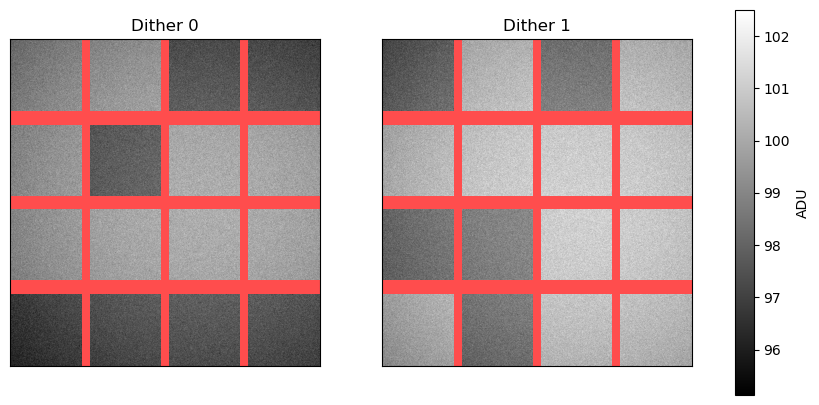

In [ ]:
_, axes = plt.subplots(1, 2, figsize=(11, 5))
data = np.array([fpa1, fpa2])
norm1 = ImageNormalize(data, interval=ZScaleInterval())
cmap = plt.get_cmap("gray")
cmap.set_bad("red", alpha=0.7)
axes[0].imshow(fpa1, cmap=cmap, norm=norm1, origin="lower", interpolation=None)
axes[0].set_title("Dither 0")
axes[1].imshow(fpa2, cmap=cmap, norm=norm1, origin="lower", interpolation=None)
axes[1].set_title("Dither 1")
plt.colorbar(axes[0].images[0], ax=axes, orientation="vertical", label="ADU")

# Make ticks and tick labels invisible
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])


## measure offsets

In [ ]:
res=measure_offset_per_observation(
    default_data_path("Q1_R1_mock", "continuity", "sky"),
    "2683",
    NISP,
    "H",
)

[-3.04797277 -3.03263536 -3.03172563 -3.00522928 -3.0039939  -3.00336281
 -3.00217819 -2.99886352 -2.99360899 -2.99303924 -2.98419671 -2.97598442
 -1.04103418 -1.02183054 -1.00685793 -1.00573838 -1.00411017 -1.0036541
 -1.00295331 -1.0021578  -0.99962598 -0.99780278 -0.99659255 -0.99544305
 -0.99246164 -0.99230573 -0.98213917 -0.98033855 -0.97729718 -0.9698286
 -0.96711667 -0.96166197 -0.94532855  0.94838194  0.9942212   1.00053687
  1.00821048  1.0090276   1.01819645  1.07568536]
[0.02976981 0.03045354 0.03137988 0.0286094  0.00391447 0.0039171
 0.00391701 0.00391418 0.03165671 0.00392127 0.02915545 0.02884308
 0.01755783 0.03107566 0.01782306 0.03005846 0.00391884 0.03108201
 0.00391508 0.00391878 0.0039169  0.0039141  0.00392019 0.00391161
 0.01813696 0.00391247 0.0305062  0.02997186 0.01815222 0.03060238
 0.03081194 0.0301839  0.02905226 0.02946967 0.00391863 0.003921
 0.03307067 0.003915   0.03059854 0.03059074]


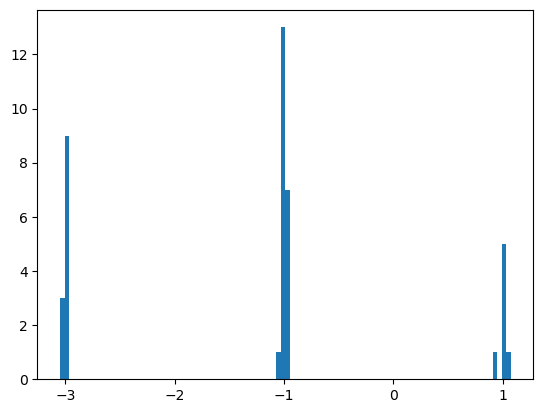

In [ ]:
offsets=np.array(res[0]["offset"])
# sort the offsets in the first column and its errors in the second column
offsets = np.array(sorted(offsets, key=lambda x: x[0]))
print(offsets[:, 0])
print(offsets[:, 1])
plt.hist(offsets[:, 0], bins=100);

## correct for the offsets

In [ ]:
solutions = solve_for_correction_per_observation(res)
print(solutions)

number of equations:  40
number of unknowns:  32
rank: 31, residuals: 0.0769298919530358
{'1.DET11': -1.2418973350248084, '1.DET12': 0.7543271048196503, '1.DET13': -1.2600834777431154, '1.DET14': -1.2721716079655583, '1.DET21': 0.7744740167015227, '1.DET22': 0.7340416278321837, '1.DET23': -1.247159272643964, '1.DET24': -1.2511958228844904, '1.DET31': -1.2867061090176117, '1.DET32': -1.2698319179153357, '1.DET33': -1.244401478142788, '1.DET34': -1.2286655522656271, '1.DET41': 0.7463718072558314, '1.DET42': -1.2397226715485543, '1.DET43': 0.7703733705257964, '1.DET44': -1.2320743625803334, '0.DET11': 1.7511419085544362, '0.DET12': 1.7607923796890246, '0.DET13': 1.7505395485899677, '0.DET14': 1.7552681972495452, '0.DET21': -0.22658647312263785, '0.DET22': -0.2676600220925016, '0.DET23': -0.262578404045899, '0.DET24': -0.25512923671617926, '0.DET31': -0.30919902010036104, '0.DET32': 1.7398770818839144, '0.DET33': -0.2442542737286262, '0.DET34': -0.22602411353808252, '0.DET41': -0.274279593

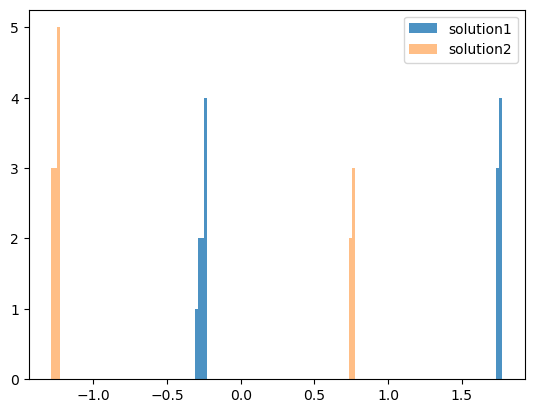

In [ ]:
solution1 = [value for key, value in solutions.items() if key.startswith("0")]
solution2 = [value for key, value in solutions.items() if key.startswith("1")]
plt.hist(solution1, bins=100, alpha=0.8, label="solution1");
plt.hist(solution2, bins=100, alpha=0.5, label="solution2");
plt.legend();


In [ ]:
apply_correction(default_data_path("Q1_R1_mock", "continuity", "sky"),
    "2683",
    NISP,
    "H",
    solutions,
    out_dir=default_data_path("Q1_R1_mock", "continuity", "sky_corr"),
    overwrite=True,
)

In [ ]:
with fits.open("~/euclid_data/Q1_R1_mock/continuity/sky_corr/EUC_NIR_W-CAL-IMAGE_H-2683-0_mock_corr.fits") as hdul:
    fpa1_corr = assemble_fpa_mosaic(hdul, instrument="NISP", binsize=10, unify_zpt=30)
with fits.open("~/euclid_data/Q1_R1_mock/continuity/sky_corr/EUC_NIR_W-CAL-IMAGE_H-2683-1_mock_corr.fits") as hdul:
    fpa2_corr = assemble_fpa_mosaic(hdul, instrument="NISP", binsize=10, unify_zpt=30)


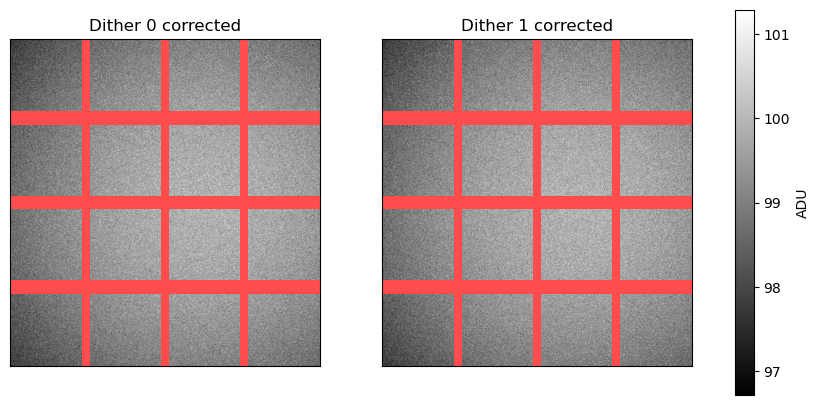

In [ ]:
_, axes = plt.subplots(1, 2, figsize=(11, 5))
data = np.array([fpa1_corr, fpa2_corr])
norm1 = ImageNormalize(data, interval=ZScaleInterval())
axes[0].imshow(fpa1_corr, cmap=cmap, norm=norm1, origin="lower", interpolation=None)
axes[0].set_title("Dither 0 corrected")
axes[1].imshow(fpa2_corr, cmap=cmap, norm=norm1, origin="lower", interpolation=None)
axes[1].set_title("Dither 1 corrected")
plt.colorbar(axes[0].images[0], ax=axes, orientation="vertical", label="ADU")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

## Combine the two dithers and compare the results

In [ ]:
from nicl.euclid.combine import combine
in_dir = default_data_path("Q1_R1_mock", "continuity", "sky")
out_dir = in_dir
combine(
    in_dir=in_dir,
    out_dir=out_dir,
    obs_ids=2683,
    filters=["H"],
    bkg_sub=False,
    pixel_scale=0.3,
)

Initialized NISPCombiner(obsids=[2683], filters=['H'], cutout_cen=ALL, cutout_size=AUTO, pixel_scale=0.30 arcsec/pix, bkg_sub=False)
Found 2 H dithers for 1 obsids. Expected 4 dithers.
Preparing science and weight images took 0.0 mins.
Running SWarp: swarp @images.list -c config.swarp -PIXEL_SCALE 0.3
SWarp finished successfully. Elapsed time: 0.3 mins.
Postprocessing took 1.8 secs. Output saved to /home/ppzhg/euclid_data/Q1_R1_mock/continuity/sky/EUC_NIR_W-STK_H-2683.fits


In [ ]:
from nicl.euclid.combine import combine
in_dir = default_data_path("Q1_R1_mock", "continuity", "sky_corr")
out_dir = in_dir
combine(
    in_dir=in_dir,
    out_dir=out_dir,
    obs_ids=2683,
    filters=["H"],
    bkg_sub=False,
    pixel_scale=0.3,
)

Initialized NISPCombiner(obsids=[2683], filters=['H'], cutout_cen=ALL, cutout_size=AUTO, pixel_scale=0.30 arcsec/pix, bkg_sub=False)
Found 2 H dithers for 1 obsids. Expected 4 dithers.
Preparing science and weight images took 0.1 mins.
Running SWarp: swarp @images.list -c config.swarp -PIXEL_SCALE 0.3
SWarp finished successfully. Elapsed time: 0.3 mins.
Postprocessing took 1.8 secs. Output saved to /home/ppzhg/euclid_data/Q1_R1_mock/continuity/sky_corr/EUC_NIR_W-STK_H-2683.fits


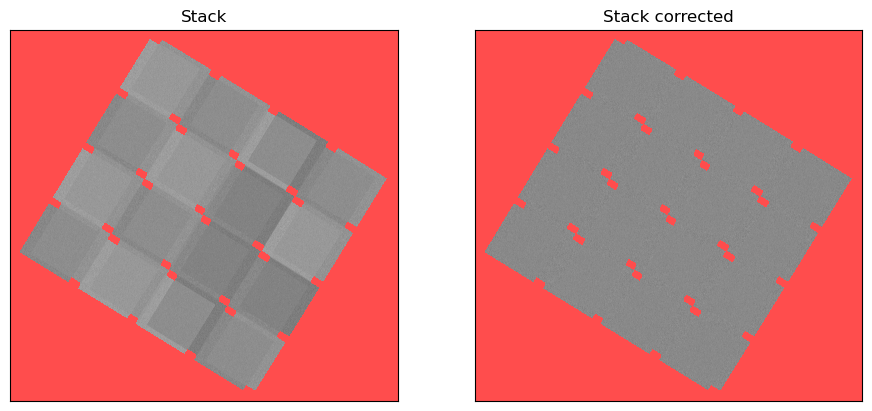

In [ ]:
stack = fits.getdata(default_data_path("Q1_R1_mock", "continuity", "sky")/"EUC_NIR_W-STK_H-2683.fits", 1)
stack_corr = fits.getdata(default_data_path("Q1_R1_mock", "continuity", "sky_corr")/"EUC_NIR_W-STK_H-2683.fits", 1)
_, axes = plt.subplots(1, 2, figsize=(11, 5))
norm1 = ImageNormalize(stack, interval=ZScaleInterval())
norm2 = ImageNormalize(stack_corr, interval=ZScaleInterval())
axes[0].imshow(stack, cmap=cmap, norm=norm1, origin="lower", interpolation=None)
axes[0].set_title("Stack")
axes[1].imshow(stack_corr, cmap=cmap, norm=norm2, origin="lower", interpolation=None)
axes[1].set_title("Stack corrected")
# plt.colorbar(axes[0].images[0], ax=axes, orientation="vertical", label="ADU")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

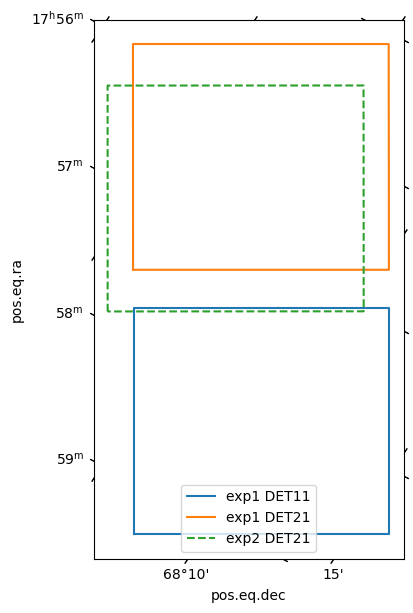

In [ ]:
dither_path1 = (
    default_data_path("Q1_R1", "NIR", "2683")
    / "EUC_NIR_W-CAL-IMAGE_H-2683-0_20240930T184607.344746Z.fits"
)
dither_path2 = (
    default_data_path("Q1_R1", "NIR", "2683")
    / "EUC_NIR_W-CAL-IMAGE_H-2683-1_20240930T184607.455806Z.fits"
)
with fits.open(dither_path1) as hdul1, fits.open(dither_path2) as hdul2:
    hdu_11 = hdul1["DET11.SCI"]
    hdu_21 = hdul1["DET21.SCI"]
    hdu_11_ = hdul2["DET21.SCI"]
    hdr_11 = hdu_11.header
    hdr_21 = hdu_21.header
    hdr_11_ = hdu_11_.header
    poly1=SphericalPolygon.from_wcs(hdr_11, steps=10)
    poly2=SphericalPolygon.from_wcs(hdr_21, steps=10)
    poly3=SphericalPolygon.from_wcs(hdr_11_, steps=10)
    ra1, dec1 = list(poly1.to_radec())[0]
    ra2, dec2 = list(poly2.to_radec())[0]
    ra3, dec3 = list(poly3.to_radec())[0]
    wcs = WCS(hdu_11.header)
    fig = plt.figure(figsize=(4, 7))
    ax=plt.subplot(1, 1, 1, projection=wcs)
    ax.plot(ra1, dec1, '-', linewidth=1.5, transform=ax.get_transform('world'), label="exp1 "+hdr_11["extname"].strip(".SCI"))
    ax.plot(ra2, dec2, '-', linewidth=1.5, transform=ax.get_transform('world'), label="exp1 "+hdr_21["extname"].strip(".SCI"))
    ax.plot(ra3, dec3, '--', linewidth=1.5, transform=ax.get_transform('world'), label="exp2 "+hdr_11_["extname"].strip(".SCI"))
    ax.legend()
    

In [ ]:
obs_id = 3587
dither_id = "2-1"
dither_id1 = "3-1"
dither_id2 = "1-1"
path = list(
    default_data_path("Q1_R1", "VIS_QUAD", str(obs_id)).glob(f"*{dither_id}*.fits")
)[0]
fn1 = list(default_data_path("Q1_R1", "VIS_QUAD", str(obs_id)).glob(f"*{dither_id1}*.fits"))[0]
fn2 = list(
    default_data_path("Q1_R1", "VIS_QUAD", str(obs_id)).glob(f"*{dither_id2}*.fits")
)[0]
# obs_id_, dither_id_, quad_id1, quad_id2, edge_diff, edge_diff_rms = measure_edge_diff(
#     fn, window=10
# )

In [ ]:
from regions import RectanglePixelRegion, PixCoord
from nicl.utilities import does_image_overlap_with_skyregion
from astropy.wcs import WCS
ext_id = "3-3.H"
top_ext_id = "4-3.E"
window = 100
hdul = fits.open(path)
hdul1 = fits.open(fn1)
hdul2 = fits.open(fn2)
img = hdul[ext_id + ".SCI"].data
hdr = hdul[ext_id + ".SCI"].header
img_top = hdul[top_ext_id + ".SCI"].data
hdr_top = hdul[top_ext_id + ".SCI"].header
nx = hdr["NAXIS1"]
ny = hdr["NAXIS2"]
pix_reg = RectanglePixelRegion(
        center=PixCoord((nx - 1) / 2, ny-(window - 1) / 2-1), width=nx, height=window
    )
pix_reg_bottom_edge = RectanglePixelRegion(
        center=PixCoord((nx - 1) / 2, (window - 1) / 2), width=nx, height=window
    )
sky_reg_top_edge = pix_reg.to_sky(WCS(hdr))
sky_reg_bottom_edge = pix_reg_bottom_edge.to_sky(WCS(hdr_top))
for chip in VIS.extnames:
    hdr = hdul1[chip + ".SCI"].header
    if does_image_overlap_with_skyregion(hdr, sky_reg_top_edge) or does_image_overlap_with_skyregion(hdr, sky_reg_bottom_edge):
        print(dither_id1, chip, does_image_overlap_with_skyregion(hdr, sky_reg_top_edge), does_image_overlap_with_skyregion(hdr, sky_reg_bottom_edge))
    hdr2 = hdul2[chip + ".SCI"].header
    if does_image_overlap_with_skyregion(hdr2, sky_reg_top_edge) or does_image_overlap_with_skyregion(hdr2, sky_reg_bottom_edge):
        print(dither_id2, chip, does_image_overlap_with_skyregion(hdr2, sky_reg_top_edge), does_image_overlap_with_skyregion(hdr2, sky_reg_bottom_edge))


3-1 3-3.G True True
3-1 3-3.H True True
1-1 4-3.E True True


In [ ]:
from reproject import reproject_interp
from reproject.mosaicking import find_optimal_celestial_wcs

common_wcs, common_shape = find_optimal_celestial_wcs([hdul[top_ext_id + ".SCI"], hdul[ext_id + ".SCI"]])
img_reproj = reproject_interp(hdul[ext_id + ".SCI"], common_wcs, shape_out=common_shape, parallel=True, return_footprint=False)
img_top_reproj = reproject_interp(hdul[top_ext_id + ".SCI"], common_wcs, shape_out=common_shape, parallel=True, return_footprint=False)
img1_dither1 = reproject_interp(hdul1["3-3.G.SCI"], common_wcs, shape_out=common_shape, parallel=True, return_footprint=False)
img2_dither1 = reproject_interp(hdul1["3-3.H.SCI"], common_wcs, shape_out=common_shape, parallel=True, return_footprint=False)
img_dither2 = reproject_interp(hdul2["4-3.E.SCI"], common_wcs, shape_out=common_shape, parallel=True, return_footprint=False)


<matplotlib.patches.Rectangle>

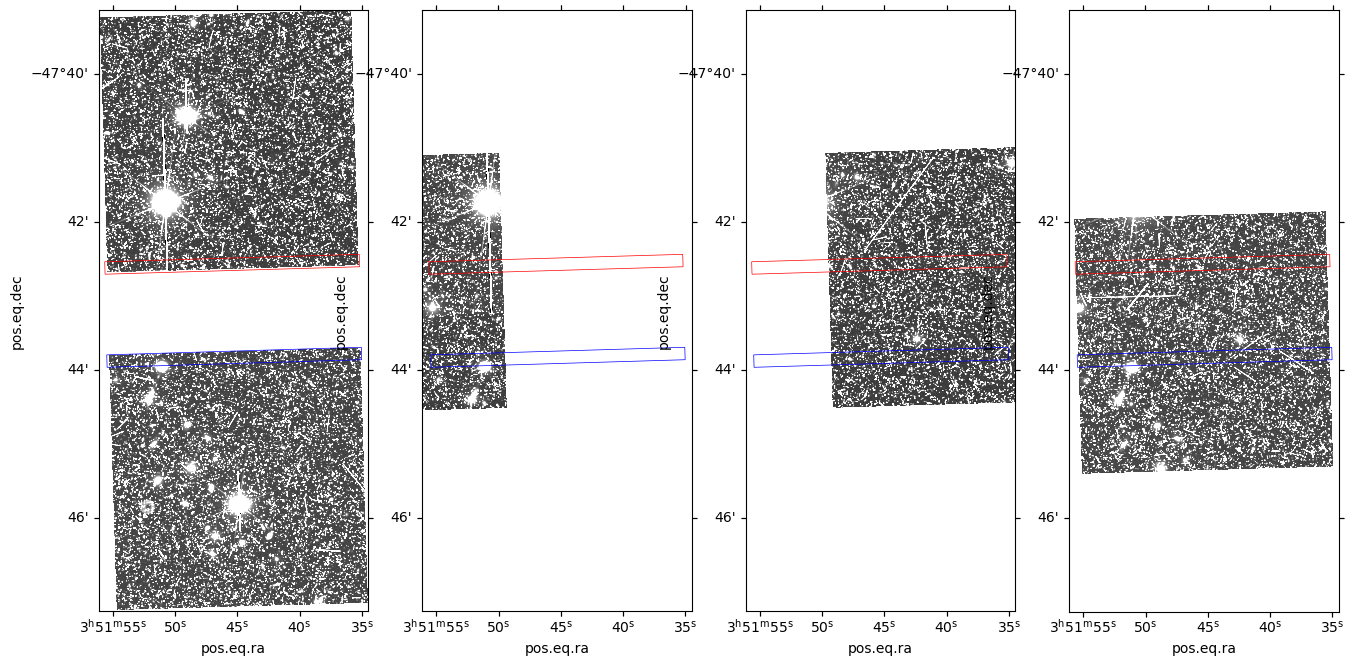

In [ ]:
from astropy.visualization import ImageNormalize, ZScaleInterval
from matplotlib import pyplot as plt

# Create a combined array of values from both images for normalization
combined_data = np.concatenate([
    img_reproj[~np.isnan(img_reproj)].flatten(),
    img_top_reproj[~np.isnan(img_top_reproj)].flatten()
])

# Create normalization based on the combined data
norm1 = ImageNormalize(
    combined_data,
    interval=ZScaleInterval(),
)
fig = plt.figure(figsize=(16, 8))
axes = [plt.subplot(1, 4, i+1, projection=common_wcs) for i in range(4)]
axes[0].imshow(
    img_reproj,
    norm=norm1,
    origin="lower",
    cmap="gray",
)
axes[0].imshow(
    img_top_reproj,
    norm=norm1,
    origin="lower",
    cmap="gray",
)
sky_reg_top_edge.to_pixel(common_wcs).plot(ax=axes[0], color="red", lw=0.5)
sky_reg_bottom_edge.to_pixel(common_wcs).plot(ax=axes[0], color="blue", lw=0.5)

axes[1].imshow(
    img1_dither1,
    norm=norm1,
    origin="lower",
    cmap="gray",
)
sky_reg_top_edge.to_pixel(common_wcs).plot(ax=axes[1], color="red", lw=0.5)
sky_reg_bottom_edge.to_pixel(common_wcs).plot(ax=axes[1], color="blue", lw=0.5)

axes[2].imshow(
    img2_dither1,
    norm=norm1,
    origin="lower",
    cmap="gray",
)
sky_reg_top_edge.to_pixel(common_wcs).plot(ax=axes[2], color="red", lw=0.5)
sky_reg_bottom_edge.to_pixel(common_wcs).plot(ax=axes[2], color="blue", lw=0.5)

axes[3].imshow(
    img_dither2,
    norm=norm1,
    origin="lower",
    cmap="gray",
)
sky_reg_top_edge.to_pixel(common_wcs).plot(ax=axes[3], color="red", lw=0.5)
sky_reg_bottom_edge.to_pixel(common_wcs).plot(ax=axes[3], color="blue", lw=0.5)


In [ ]:
# | hide
import nbdev

nbdev.nbdev_export()